In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
#run from repo root...
os.chdir(r"C:/Users/jamed\Documents/repos/terrain_classification_project/TerrainClassificationForFloodModelling")

In [3]:
from structured_data_utils.data import ModelData
from structured_data_utils.structured_data_interfacing import standardise_dataset


In [4]:
standardise_dataset("WILLOWAN", force=True)

In [5]:
willowan_data = ModelData()
willowan_data.prepare_data("WILLOWAN", sliding_window_size=200, stride=100)

pad_x: 1320, pad_y: 1028
1257.0
starting
No rotation angles provided, using generator...
Using rotation angles: [58, 105, 107, 63, 59, 89, 26, 27, 178, 78, 118, 166, 33, 113, 32, 122, 101, 121, 79, 35, 171, 96, 173, 16, 128, 167, 59, 76, 100, 45, 25, 59, 166, 113, 31, 1, 25, 14, 98, 38, 51, 114, 143, 75, 99, 30, 111, 118, 110, 149, 78, 149, 20, 100, 89, 42, 128, 143, 146, 76, 2, 167, 15, 136, 167, 68, 37, 10, 122, 144, 160, 39, 106, 52, 132, 180, 154, 155, 149, 141, 75, 169, 118, 27, 93, 18, 147, 86, 115, 90, 127, 32, 34, 78, 117, 33, 45, 142, 128, 156, 92, 64, 125, 114, 14, 1, 59, 120, 12, 45, 40, 180, 101, 144, 1, 40, 159, 18, 161, 92, 22, 104, 17, 118, 117, 6, 78, 74, 178, 156, 56, 65, 32, 19, 153, 30, 24, 5, 50, 91, 152, 169, 110, 157, 131, 19, 107, 171, 115, 13, 132, 25, 92, 160, 120, 105, 120, 180, 134, 106, 44, 91, 8, 124, 153, 110, 56, 172, 4, 93, 67, 110, 80, 11, 118, 37, 86, 153, 21, 15, 153, 19, 163, 49, 145, 53, 75, 10, 35, 84, 174, 10, 36, 166, 10, 160, 133, 64, 172, 129, 

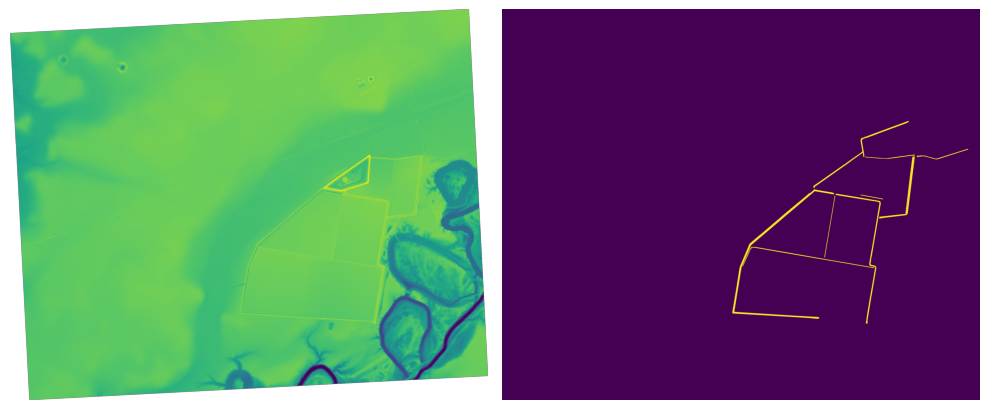

In [6]:
from model_prototyping.unet_implementation.metrics import show_matrices
show_matrices([willowan_data.data_with_labels.data[0], willowan_data.data_with_labels.labels[0]])

In [7]:
standardise_dataset("WILLOWAN", force=True)

In [8]:
#beermery_data = ModelData()
#beermery_data.prepare_data("BEERMERY", sliding_window_size=300, stride=200)

In [9]:
from model_prototyping.unet_implementation.metrics import show_matrices
#show_matrices([beermery_data.data_with_labels.data[0], beermery_data.data_with_labels.labels[0]])

In [10]:
#combined_data = ModelData.splice_model_data([beermery_data, willowan_data])

In [11]:
from model_prototyping.unet_implementation.modules import train_model, test_model_visual


In [12]:
from model_prototyping.unet_implementation.constants import (
    UNET_BLOCK_BASELINE,
    UNET_BLOCK_PREACT,
    UNET_BLOCK_DROPOUT,
    UNET_BLOCK_DILATED,
    UNET_BLOCK_RESIDUAL,
)


In [13]:
willowan_data.data_with_labels.data.shape

torch.Size([1, 2135, 2610])


Training Complete!


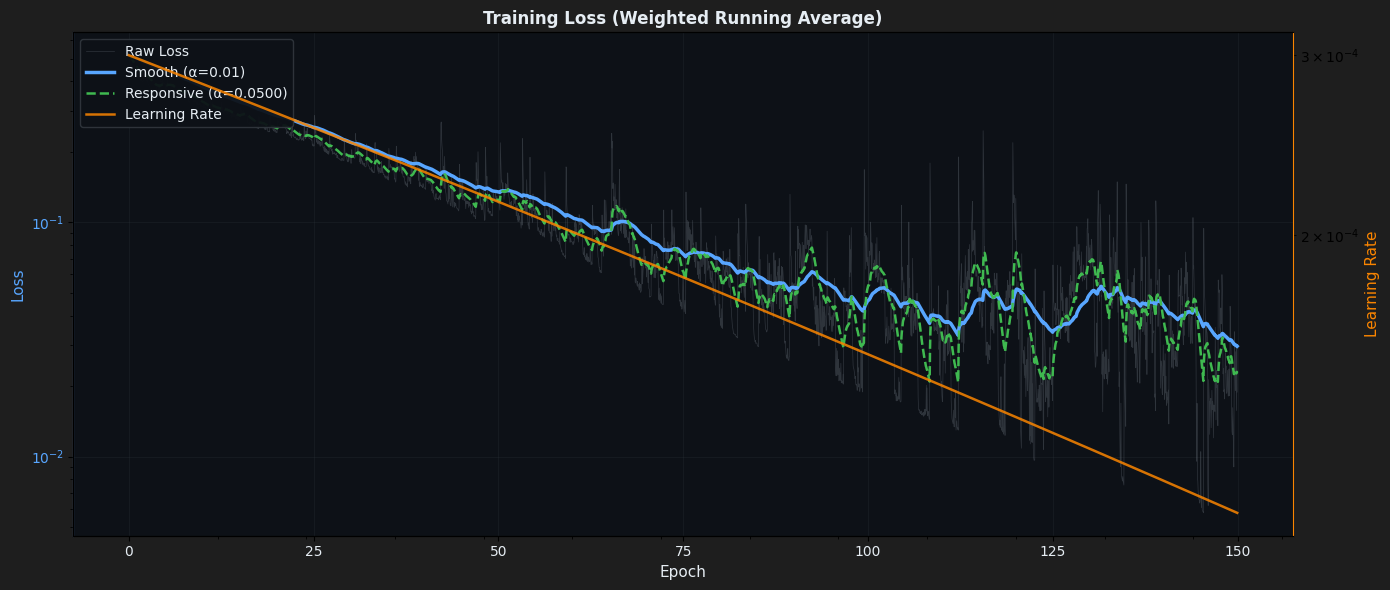


Loss Statistics:
  Initial loss: 0.517417
  Final loss: 0.018849
  Min loss: 0.005753
  Max loss: 0.517417
  Final smooth average: 0.029610
  Final responsive average: 0.022796
  Total steps: 2985


In [14]:
# Residual connections (skip connections within block)
model_residual = train_model(willowan_data,
                    num_epochs=150,
                    viz_every=500,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=1.00004,
                    pos_bias=1,
                    block_config=UNET_BLOCK_RESIDUAL)



Training Complete!


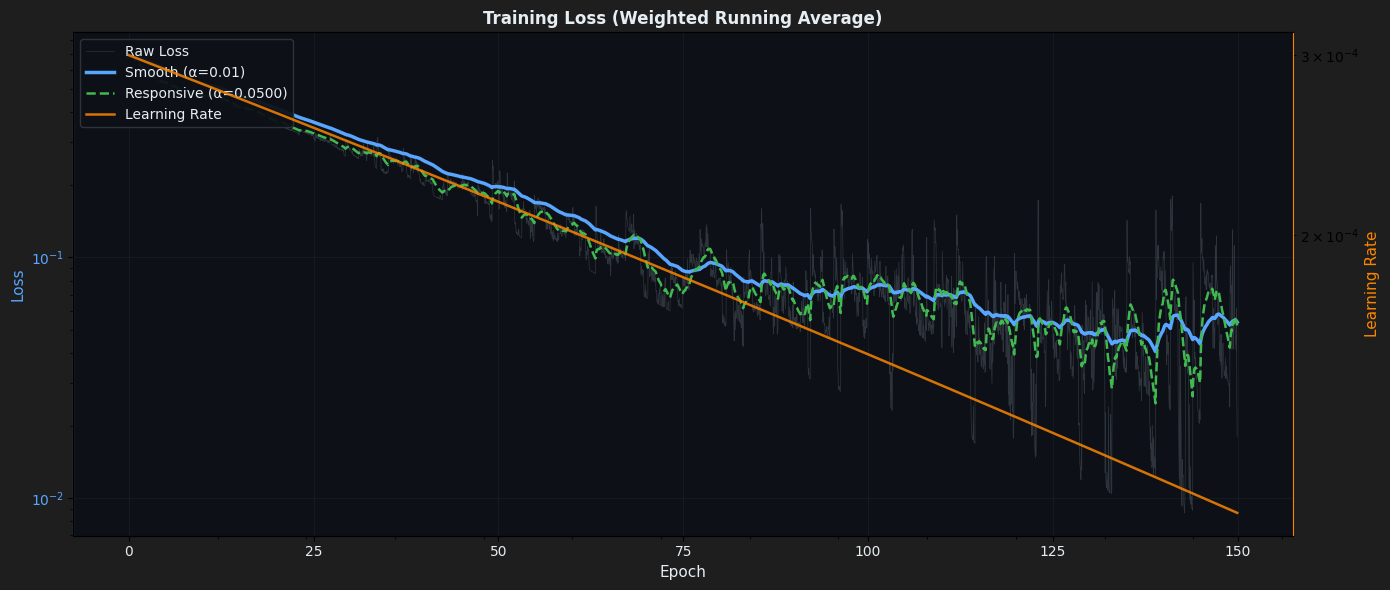


Loss Statistics:
  Initial loss: 0.689820
  Final loss: 0.018044
  Min loss: 0.008689
  Max loss: 0.689820
  Final smooth average: 0.053803
  Final responsive average: 0.051492
  Total steps: 2989


In [15]:
# Dilated convolutions (larger receptive field)
model_dilated = train_model(willowan_data,
                    num_epochs=150,
                    viz_every=500,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=1.00004,
                    pos_bias=1,
                    block_config=UNET_BLOCK_DILATED)



Training Complete!


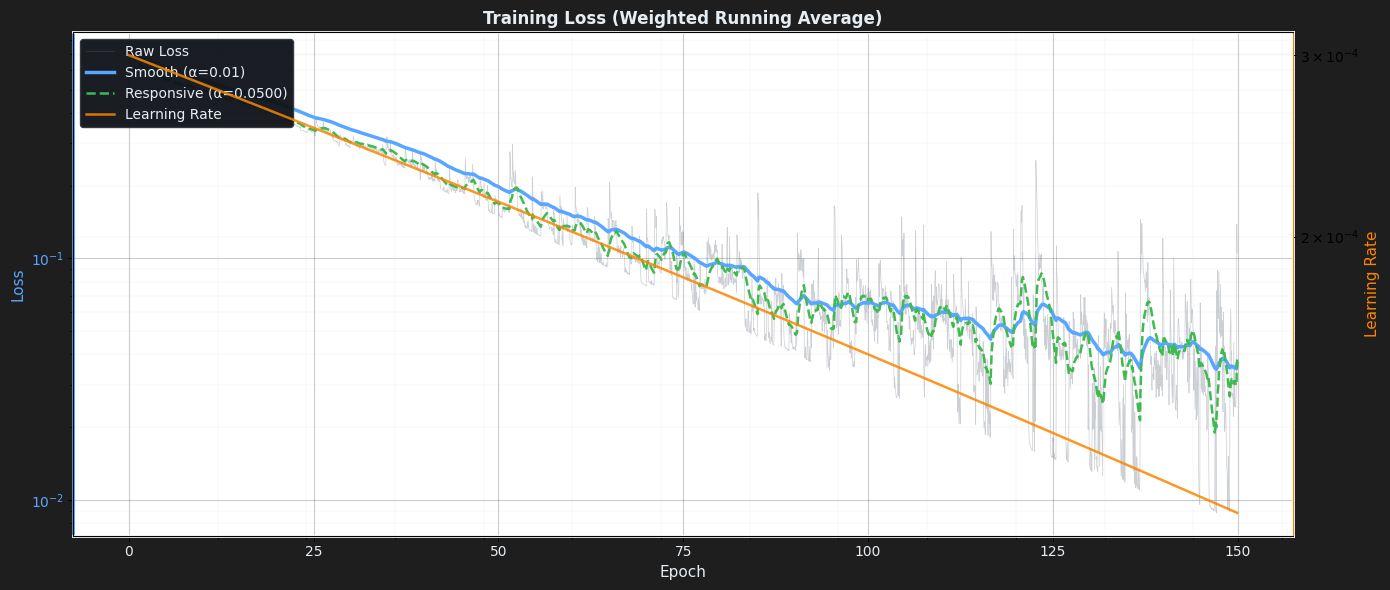


Loss Statistics:
  Initial loss: 0.693341
  Final loss: 0.105094
  Min loss: 0.008838
  Max loss: 0.693341
  Final smooth average: 0.036599
  Final responsive average: 0.038740
  Total steps: 2968


In [16]:
# Dropout-regularised block
model_dropout = train_model(willowan_data,
                    num_epochs=150,
                    viz_every=500,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=1.00004,
                    pos_bias=1,
                    block_config=UNET_BLOCK_DROPOUT)



Training Complete!


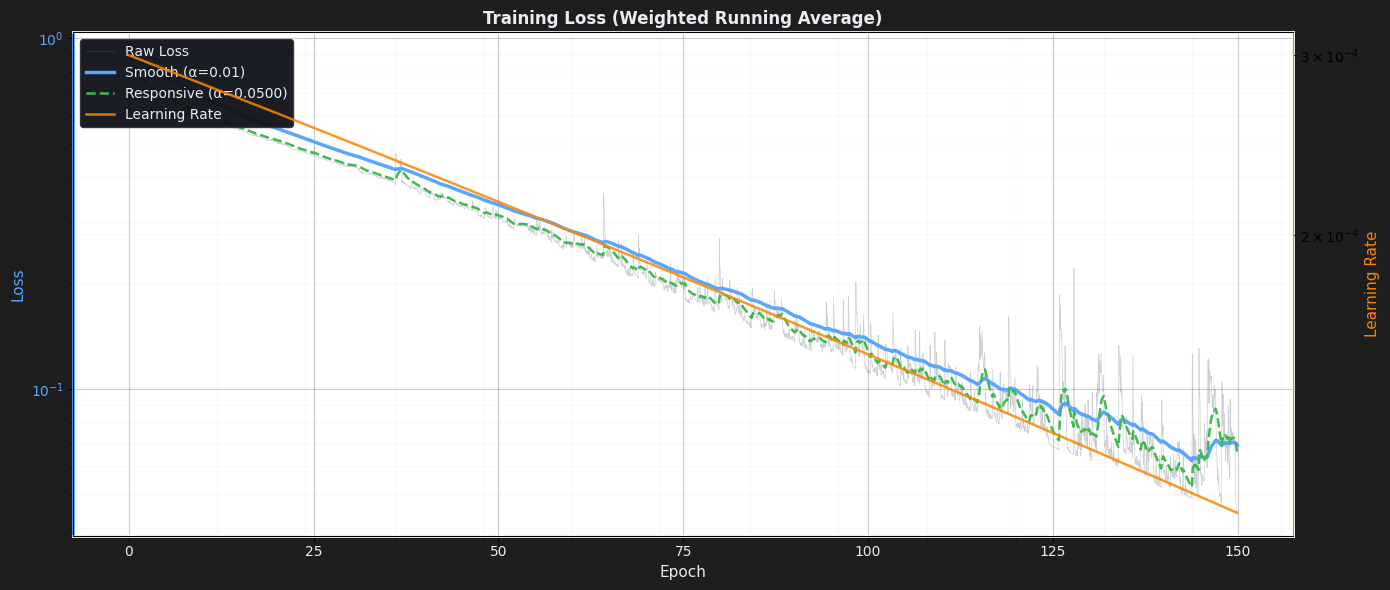


Loss Statistics:
  Initial loss: 0.894799
  Final loss: 0.044721
  Min loss: 0.044508
  Max loss: 0.894799
  Final smooth average: 0.069377
  Final responsive average: 0.065912
  Total steps: 2989


In [17]:
# Pre-activation: GN → ReLU → Conv (repeats)
model_preact = train_model(willowan_data,
                    num_epochs=150,
                    viz_every=500,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=1.00004,
                    pos_bias=1,
                    block_config=UNET_BLOCK_PREACT)



Training Complete!


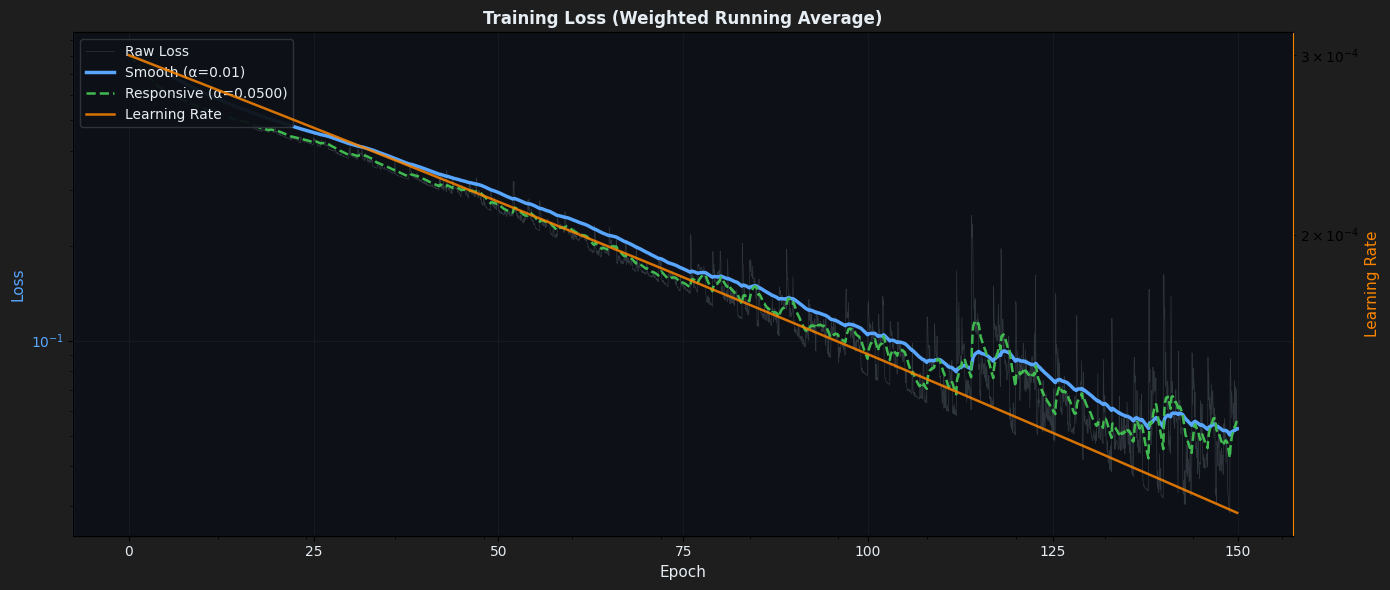


Loss Statistics:
  Initial loss: 0.803518
  Final loss: 0.053194
  Min loss: 0.028456
  Max loss: 0.803518
  Final smooth average: 0.052580
  Final responsive average: 0.055116
  Total steps: 3000


In [18]:
# Baseline: Conv → GN → ReLU → Conv → GN → ReLU
model_baseline = train_model(willowan_data,
                    num_epochs=150,
                    viz_every=500,
                    features=[8,16,32],
                    lr=3e-4,
                    lr_decay=1.00004,
                    pos_bias=1,
                    block_config=UNET_BLOCK_BASELINE)


# UNet Block Configuration Variants

Try different block architectures by passing them to train_model:


In [19]:
dont run past here

SyntaxError: invalid syntax (3924499446.py, line 1)

In [ ]:
import torch
model_path ="C:\\Users\\jamed\\Documents\\repos\\terrain_classification_project\\QuickTerrainClassification\\data\\model.pth"

In [ ]:
# Create sample input with same shape as training data
sample_input = torch.randn(1, 1, 1000, 1000).to(torch.device("cuda" if torch.cuda.is_available() else "cpu"))
model_dilated.eval()
scripted = torch.jit.trace(model_dilated, sample_input)
scripted.save(model_path)